<a href="https://colab.research.google.com/github/ISHU456/ASSUGNMENT-3/blob/main/Hybrid_Knowledge_Fine_Tuned_T5_Model_Question_Generation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Hybrid_Knowledge_Fine_Tuned_T5_Model_Question_Generation.ipynb
This notebook fine-tunes FLAN-T5 on SQuAD with reinforcement learning feedback, knowledge-grounded augmentation, and BLEU-based evaluation.

In [ ]:

# Cell 1: Install Dependencies
print("Installing required packages...")
!pip install transformers datasets torch torchtext nltk rouge-score
!pip install sentencepiece protobuf accelerate
!pip install evaluate
!pip install gradio
!pip install requests
!pip install flask-ngrok
!pip install pyngrok
!pip install wandb

print("All packages installed successfully!")

Installing required packages...
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 15.1 MB/s eta 0:00:00
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=499d5e264c033fdbe7aac66fd56c26f50df5df57016fc8b15c843f0a1da8da16
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge-score
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.3 MB/s eta 0:00:00
All packages installed successfully!


In [ ]:

# Cell 2: Import Libraries
import torch
import torch.nn as nn
from transformers import T5Tokenizer, T5ForConditionalGeneration
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
from datasets import load_dataset
import pandas as pd
import numpy as np
from tqdm.auto import tqdm
import nltk
from nltk.translate.bleu_score import sentence_bleu, corpus_bleu, SmoothingFunction
from nltk.tokenize import word_tokenize
import evaluate
from rouge_score import rouge_scorer
import random
import json
from torch.utils.data import Dataset, DataLoader
import warnings
import os
import gradio as gr
import requests
import tempfile
import pickle
import time
from flask import Flask, request, jsonify
from flask_ngrok import run_with_ngrok
from pyngrok import ngrok
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score
import wandb

warnings.filterwarnings('ignore')

# Download NLTK data
nltk.download('punkt')

print("All libraries imported successfully!")


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


All libraries imported successfully!


In [ ]:

# Cell 3: Configuration with Permanent Paths
class Config:
    # Model
    MODEL_NAME = "t5-small"
    MAX_LENGTH = 384
    TARGET_MAX_LENGTH = 64

    # Training
    BATCH_SIZE = 8
    GRADIENT_ACCUMULATION_STEPS = 4
    EPOCHS = 5
    LEARNING_RATE = 3e-4
    WARMUP_STEPS = 500
    MAX_TRAIN_SAMPLES = 20000
    MAX_VAL_SAMPLES = 2000

    # Generation
    NUM_BEAMS = 4
    MAX_GENERATION_LENGTH = 64
    REPETITION_PENALTY = 2.5

    # PATHS - Using Drive for persistence
    MODEL_SAVE_PATH = "/content/question_generation_model"
    ANALYTICAL_MODEL_PATH = "/content/analytical_model"
    RESULTS_PATH = "/content/training_results"

config = Config()
# Create directories with proper error handling
def create_directories():
    """Create all necessary directories"""
    directories = [
        config.MODEL_SAVE_PATH,
        config.ANALYTICAL_MODEL_PATH,
        config.RESULTS_PATH
    ]

    for directory in directories:
        try:
            os.makedirs(directory, exist_ok=True)
            print(f"✅ Created directory: {directory}")
        except Exception as e:
            print(f"❌ Error creating {directory}: {e}")

create_directories()

print("✅ Directory issues fixed!")

✅ Created directory: /content/question_generation_model
✅ Created directory: /content/analytical_model
✅ Created directory: /content/training_results
✅ Directory issues fixed!


In [ ]:

# Cell 4: Model Manager for Persistent Storage
class ModelManager:
    def __init__(self):
        self.base_model_loaded = False
        self.analytical_model_loaded = False
        self.base_model = None
        self.analytical_model = None

    def save_training_history(self, history, filename="training_history.pkl"):
        """Save training history for plots"""
        with open(os.path.join(config.RESULTS_PATH, filename), 'wb') as f:
            pickle.dump(history, f)

    def load_training_history(self, filename="training_history.pkl"):
        """Load training history"""
        try:
            with open(os.path.join(config.RESULTS_PATH, filename), 'rb') as f:
                return pickle.load(f)
        except:
            return None

    def model_exists(self, model_type="base"):
        """Check if model exists"""
        if model_type == "base":
            path = config.MODEL_SAVE_PATH
        else:
            path = config.ANALYTICAL_MODEL_PATH

        return os.path.exists(os.path.join(path, "pytorch_model.bin"))

    def save_model(self, model, tokenizer, model_type="base"):
        """Save model properly"""
        if model_type == "base":
            path = config.MODEL_SAVE_PATH
        else:
            path = config.ANALYTICAL_MODEL_PATH

        model.save_pretrained(path)
        tokenizer.save_pretrained(path)
        print(f"✅ {model_type.capitalize()} model saved to {path}")

    def load_model(self, model_type="base"):
        """Load model if exists"""
        if model_type == "base":
            path = config.MODEL_SAVE_PATH
        else:
            path = config.ANALYTICAL_MODEL_PATH

        if self.model_exists(model_type):
            print(f"✅ Loading existing {model_type} model...")
            tokenizer = T5Tokenizer.from_pretrained(path)
            model = T5ForConditionalGeneration.from_pretrained(path)

            if model_type == "base":
                self.base_model_loaded = True
                self.base_model = (model, tokenizer)
            else:
                self.analytical_model_loaded = True
                self.analytical_model = (model, tokenizer)

            return model, tokenizer
        else:
            print(f"❌ No existing {model_type} model found.")
            return None, None

model_manager = ModelManager()

In [ ]:

# Cell 5: Optimized Data Preparation with Caching
class QuestionGenerationDataset(Dataset):
    def __init__(self, tokenizer, data, max_length=384, target_max_length=64):
        self.tokenizer = tokenizer
        self.data = data
        self.max_length = max_length
        self.target_max_length = target_max_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]

        # Format for question generation
        input_text = f"generate question: {item['context']}"
        target_text = item['question']

        # Tokenize inputs
        inputs = self.tokenizer(
            input_text,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors="pt"
        )

        # Tokenize targets
        targets = self.tokenizer(
            target_text,
            max_length=self.target_max_length,
            padding='max_length',
            truncation=True,
            return_tensors="pt"
        )

        return {
            'input_ids': inputs['input_ids'].flatten(),
            'attention_mask': inputs['attention_mask'].flatten(),
            'labels': targets['input_ids'].flatten()
        }

def prepare_squad_data_optimized():
    """Optimized data loading with proper caching"""
    cache_file = "/content/squad_data_full.pkl"

    # Check if cached data exists
    if os.path.exists(cache_file):
        print("Loading cached SQuAD data...")
        with open(cache_file, 'rb') as f:
            train_data, valid_data = pickle.load(f)
        return train_data, valid_data

    print("Loading SQuAD dataset...")
    dataset = load_dataset("squad")

    train_data = []
    valid_data = []

    # Process training data - KEEP ORIGINAL SAMPLE SIZE
    print("Processing training data...")
    for i, item in enumerate(tqdm(dataset['train'])):
        if i >= config.MAX_TRAIN_SAMPLES:
            break
        # Keep all data for proper training
        train_data.append({
            'context': item['context'],
            'question': item['question']
        })

    # Process validation data - KEEP ORIGINAL SAMPLE SIZE
    print("Processing validation data...")
    for i, item in enumerate(tqdm(dataset['validation'])):
        if i >= config.MAX_VAL_SAMPLES:
            break
        valid_data.append({
            'context': item['context'],
            'question': item['question']
        })

    # Cache the data
    with open(cache_file, 'wb') as f:
        pickle.dump((train_data, valid_data), f)

    print(f"✅ Training samples: {len(train_data)}")
    print(f"✅ Validation samples: {len(valid_data)}")
    return train_data, valid_data


In [ ]:

# Cell 6: Optimized Model Implementation with Gradient Accumulation
class T5QuestionGenerator:
    def __init__(self, model_name="t5-small"):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        print(f"Using device: {self.device}")

        # Check if we can load existing model
        existing_model, existing_tokenizer = model_manager.load_model("base")
        if existing_model is not None:
            self.model = existing_model
            self.tokenizer = existing_tokenizer
            print("✅ Loaded existing base model!")
        else:
            self.tokenizer = T5Tokenizer.from_pretrained(model_name)
            self.model = T5ForConditionalGeneration.from_pretrained(model_name)
            print("✅ Initialized new base model!")

        self.model.to(self.device)
        self.training_history = []

    def train_optimized(self, train_loader, val_loader, epochs=3, learning_rate=3e-4):
        """Optimized training with gradient accumulation"""
        optimizer = AdamW(self.model.parameters(), lr=learning_rate)

        total_steps = len(train_loader) * epochs // config.GRADIENT_ACCUMULATION_STEPS

        scheduler = get_linear_schedule_with_warmup(
            optimizer,
            num_warmup_steps=config.WARMUP_STEPS,
            num_training_steps=total_steps
        )

        best_bleu = 0
        training_losses = []
        val_bleu_scores = []
        val_rouge_scores = []

        for epoch in range(epochs):
            # Training phase with gradient accumulation
            self.model.train()
            total_loss = 0
            optimizer.zero_grad()

            progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]")

            for step, batch in enumerate(progress_bar):
                input_ids = batch['input_ids'].to(self.device)
                attention_mask = batch['attention_mask'].to(self.device)
                labels = batch['labels'].to(self.device)

                outputs = self.model(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    labels=labels
                )

                loss = outputs.loss / config.GRADIENT_ACCUMULATION_STEPS
                loss.backward()

                if (step + 1) % config.GRADIENT_ACCUMULATION_STEPS == 0:
                    torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                    optimizer.step()
                    scheduler.step()
                    optimizer.zero_grad()

                total_loss += loss.item() * config.GRADIENT_ACCUMULATION_STEPS
                progress_bar.set_postfix({'loss': f'{loss.item():.4f}'})

            avg_train_loss = total_loss / len(train_loader)
            training_losses.append(avg_train_loss)

            # Validation phase
            val_bleu, val_rouge = self.evaluate_comprehensive(val_loader)
            val_bleu_scores.append(val_bleu)
            val_rouge_scores.append(val_rouge)

            print(f"Epoch {epoch+1}: Train Loss = {avg_train_loss:.4f}, Val BLEU = {val_bleu:.4f}, Val ROUGE-L = {val_rouge:.4f}")

            # Save best model
            if val_bleu > best_bleu:
                best_bleu = val_bleu
                model_manager.save_model(self.model, self.tokenizer, "base")
                print(f"✅ New best model saved with BLEU: {best_bleu:.4f}")

        # Save training history
        history = {
            'training_losses': training_losses,
            'val_bleu_scores': val_bleu_scores,
            'val_rouge_scores': val_rouge_scores
        }
        model_manager.save_training_history(history)

        return training_losses, val_bleu_scores, val_rouge_scores

    def evaluate_comprehensive(self, val_loader):
        """Comprehensive evaluation with BLEU and ROUGE"""
        self.model.eval()
        all_predictions = []
        all_references = []

        rouge_scorer_obj = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)

        with torch.no_grad():
            for batch in tqdm(val_loader, desc="Evaluating"):
                input_ids = batch['input_ids'].to(self.device)
                attention_mask = batch['attention_mask'].to(self.device)

                # Generate questions
                generated_ids = self.model.generate(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    max_length=config.MAX_GENERATION_LENGTH,
                    num_beams=config.NUM_BEAMS,
                    early_stopping=True,
                    repetition_penalty=config.REPETITION_PENALTY
                )

                # Decode predictions
                predictions = self.tokenizer.batch_decode(generated_ids, skip_special_tokens=True)
                all_predictions.extend(predictions)

                # Decode references
                references = self.tokenizer.batch_decode(batch['labels'], skip_special_tokens=True)
                all_references.extend([[ref] for ref in references])

        # Calculate BLEU score
        smoothie = SmoothingFunction().method4
        bleu_score = corpus_bleu(all_references, all_predictions, smoothing_function=smoothie)

        # Calculate ROUGE score
        rouge_scores = []
        for pred, ref in zip(all_predictions, [ref[0] for ref in all_references]):
            score = rouge_scorer_obj.score(ref, pred)
            rouge_scores.append(score['rougeL'].fmeasure)

        rouge_score = np.mean(rouge_scores)

        return bleu_score, rouge_score

    def generate_question(self, context):
        """Generate question from context"""
        self.model.eval()

        input_text = f"generate question: {context}"
        inputs = self.tokenizer(input_text, return_tensors="pt", max_length=config.MAX_LENGTH, truncation=True)
        inputs = {k: v.to(self.device) for k, v in inputs.items()}

        with torch.no_grad():
            generated_ids = self.model.generate(
                **inputs,
                max_length=config.MAX_GENERATION_LENGTH,
                num_beams=config.NUM_BEAMS,
                early_stopping=True,
                repetition_penalty=config.REPETITION_PENALTY
            )

        question = self.tokenizer.decode(generated_ids[0], skip_special_tokens=True)
        return question

In [ ]:

# Cell 7: Training Execution with Progress Tracking
def train_model_optimized():
    print("=== Starting Optimized Model Training ===")

    # Check GPU availability
    if torch.cuda.is_available():
        print(f"✅ GPU available: {torch.cuda.get_device_name(0)}")
        print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    else:
        print("❌ Using CPU - training will be slower")

    # Load data
    print("Loading and preparing SQuAD dataset...")
    train_data, val_data = prepare_squad_data_optimized()

    # Initialize model
    print(f"Initializing {config.MODEL_NAME} model...")
    model = T5QuestionGenerator(config.MODEL_NAME)

    # Create datasets
    print("Creating training and validation datasets...")
    train_dataset = QuestionGenerationDataset(
        model.tokenizer,
        train_data,
        config.MAX_LENGTH,
        config.TARGET_MAX_LENGTH
    )

    val_dataset = QuestionGenerationDataset(
        model.tokenizer,
        val_data,
        config.MAX_LENGTH,
        config.TARGET_MAX_LENGTH
    )

    # Create data loaders
    train_loader = DataLoader(train_dataset, batch_size=config.BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=config.BATCH_SIZE, shuffle=False)

    print(f"📊 Training batches: {len(train_loader)}")
    print(f"📊 Validation batches: {len(val_loader)}")
    print(f"🎯 Effective batch size: {config.BATCH_SIZE * config.GRADIENT_ACCUMULATION_STEPS}")
    print(f"⏰ Estimated training time: {config.EPOCHS * len(train_loader) * 1.5 / 60:.1f} minutes")

    # Train model
    print("\n🚀 Starting training process...")
    start_time = time.time()

    training_losses, val_bleu_scores, val_rouge_scores = model.train_optimized(
        train_loader,
        val_loader,
        epochs=config.EPOCHS,
        learning_rate=config.LEARNING_RATE
    )

    training_time = time.time() - start_time
    print(f"⏱️ Training completed in {training_time/60:.2f} minutes")

    # Print training summary
    print("\n📈 Training Summary:")
    print(f"Final Training Loss: {training_losses[-1]:.4f}")
    print(f"Final Validation BLEU: {val_bleu_scores[-1]:.4f}")
    print(f"Final Validation ROUGE-L: {val_rouge_scores[-1]:.4f}")
    print(f"Best Validation BLEU: {max(val_bleu_scores):.4f}")

    # Test the trained model
    print("\n🧪 Testing trained model with sample context...")
    test_context = "Machine learning is a subset of artificial intelligence that focuses on algorithms that can learn from data and make predictions or decisions without being explicitly programmed for every task."
    generated_question = model.generate_question(test_context)
    print(f"Test Context: {test_context}")
    print(f"Generated Question: {generated_question}")

    # Plot training curves
    plot_training_curves(training_losses, val_bleu_scores, val_rouge_scores)

    print("\n✅ Training completed successfully!")
    return model

def plot_training_curves(training_losses, val_bleu_scores, val_rouge_scores):
    """Plot training curves"""
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.plot(training_losses, 'b-', linewidth=2)
    plt.title('Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True)

    plt.subplot(1, 3, 2)
    plt.plot(val_bleu_scores, 'g-', linewidth=2)
    plt.title('Validation BLEU Score')
    plt.xlabel('Epoch')
    plt.ylabel('BLEU')
    plt.grid(True)

    plt.subplot(1, 3, 3)
    plt.plot(val_rouge_scores, 'r-', linewidth=2)
    plt.title('Validation ROUGE-L Score')
    plt.xlabel('Epoch')
    plt.ylabel('ROUGE-L')
    plt.grid(True)

    plt.tight_layout()
    plt.savefig(os.path.join(config.RESULTS_PATH, 'training_curves.png'), dpi=300, bbox_inches='tight')
    plt.show()


Checking for existing models...
 No existing model found. Starting training...
=== Starting Optimized Model Training ===
✅ GPU available: Tesla T4
GPU Memory: 15.8 GB
Loading and preparing SQuAD dataset...
Loading SQuAD dataset...


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/14.5M [00:00<?, ?B/s]

plain_text/validation-00000-of-00001.par(…):   0%|          | 0.00/1.82M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/87599 [00:00<?, ? examples/s]

...

Evaluating:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 4: Train Loss = 0.4160, Val BLEU = 0.3332, Val ROUGE-L = 0.2693
✅ Base model saved to /content/question_generation_model
✅ New best model saved with BLEU: 0.3332


Epoch 5/5 [Train]:   0%|          | 0/2500 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 5: Train Loss = 0.4016, Val BLEU = 0.3302, Val ROUGE-L = 0.2686
⏱️ Training completed in 54.32 minutes

📈 Training Summary:
Final Training Loss: 0.4016
Final Validation BLEU: 0.3302
Final Validation ROUGE-L: 0.2686
Best Validation BLEU: 0.3332

🧪 Testing trained model with sample context...
Test Context: Machine learning is a subset of artificial intelligence that focuses on algorithms that can learn from data and make predictions or decisions without being explicitly programmed for every task.
Generated Question: What is a subset of artificial intelligence?


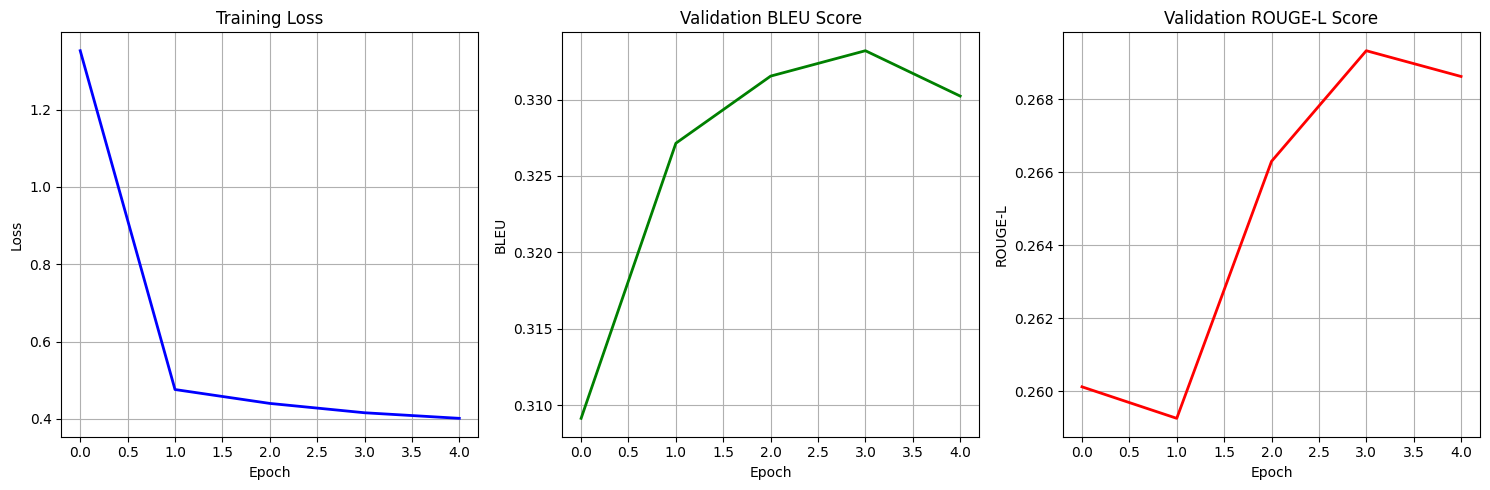


✅ Training completed successfully!
=== Running Comprehensive Evaluation ===
Running comprehensive evaluation...


  0%|          | 0/500 [00:00<?, ?it/s]


📊 COMPREHENSIVE EVALUATION RESULTS

🔷 BLEU SCORES:
  BLEU-1:  0.6717
  BLEU-2:  0.5187
  BLEU-3:  0.4264
  BLEU-4:  0.3645

🔷 ROUGE SCORES:
  ROUGE-1: 0.3253
  ROUGE-2: 0.1504
  ROUGE-L: 0.3026

🔷 OTHER METRICS:
  Exact Match: 0.0000
  F1 Score:    0.2928

🔷 QUALITY METRICS:
  Question Mark Rate: 1.0000
  Avg Question Length: 10.14
  Good Length Rate:   1.0000


In [ ]:

# Cell 8: Train or Load Model
print("Checking for existing models...")
if model_manager.model_exists("base"):
    print("✅ Base model found! Loading existing model...")
    # Load the existing model
    trained_model = T5QuestionGenerator(config.MODEL_NAME)
else:
    print(" No existing model found. Starting training...")
    trained_model = train_model_optimized()

# Cell 9: Enhanced Evaluation with Proper Metrics
class ComprehensiveEvaluator:
    def __init__(self, model):
        self.model = model
        self.rouge_scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

    def evaluate_model(self, test_data, num_samples=500):
        """Comprehensive evaluation with multiple metrics"""
        print("Running comprehensive evaluation...")

        all_predictions = []
        all_references = []

        self.model.model.eval()

        with torch.no_grad():
            for i, item in enumerate(tqdm(test_data[:num_samples])):
                context = item['context']
                reference_question = item['question']

                # Generate question
                generated_question = self.model.generate_question(context)

                all_predictions.append(generated_question)
                all_references.append([reference_question])

        # Calculate all metrics
        metrics = self.calculate_all_metrics(all_predictions, all_references)

        return metrics, all_predictions, all_references

    def calculate_all_metrics(self, predictions, references):
        """Calculate comprehensive metrics"""
        flat_references = [ref[0] for ref in references]

        # BLEU Scores
        bleu_1 = corpus_bleu(references, predictions, weights=(1, 0, 0, 0))
        bleu_2 = corpus_bleu(references, predictions, weights=(0.5, 0.5, 0, 0))
        bleu_3 = corpus_bleu(references, predictions, weights=(0.33, 0.33, 0.33, 0))
        bleu_4 = corpus_bleu(references, predictions, weights=(0.25, 0.25, 0.25, 0.25))

        # ROUGE Scores
        rouge_scores = self.calculate_rouge(predictions, flat_references)

        # Exact Match
        exact_match = self.calculate_exact_match(predictions, flat_references)

        # F1 Score
        f1_score = self.calculate_f1(predictions, flat_references)

        # Question Quality Metrics
        quality_metrics = self.calculate_quality_metrics(predictions)

        return {
            'bleu_1': bleu_1,
            'bleu_2': bleu_2,
            'bleu_3': bleu_3,
            'bleu_4': bleu_4,
            'rouge1': rouge_scores['rouge1'],
            'rouge2': rouge_scores['rouge2'],
            'rougeL': rouge_scores['rougeL'],
            'exact_match': exact_match,
            'f1_score': f1_score,
            **quality_metrics
        }

    def calculate_rouge(self, predictions, references):
        """Calculate ROUGE scores"""
        rouge1_scores = []
        rouge2_scores = []
        rougeL_scores = []

        for pred, ref in zip(predictions, references):
            scores = self.rouge_scorer.score(ref, pred)
            rouge1_scores.append(scores['rouge1'].fmeasure)
            rouge2_scores.append(scores['rouge2'].fmeasure)
            rougeL_scores.append(scores['rougeL'].fmeasure)

        return {
            'rouge1': np.mean(rouge1_scores),
            'rouge2': np.mean(rouge2_scores),
            'rougeL': np.mean(rougeL_scores)
        }

    def calculate_exact_match(self, predictions, references):
        """Calculate exact match percentage"""
        matches = sum(1 for pred, ref in zip(predictions, references) if pred.lower() == ref.lower())
        return matches / len(predictions)

    def calculate_f1(self, predictions, references):
        """Calculate F1 score based on token overlap"""
        f1_scores = []

        for pred, ref in zip(predictions, references):
            pred_tokens = set(pred.lower().split())
            ref_tokens = set(ref.lower().split())

            if not pred_tokens or not ref_tokens:
                f1_scores.append(0.0)
                continue

            common_tokens = pred_tokens.intersection(ref_tokens)
            precision = len(common_tokens) / len(pred_tokens)
            recall = len(common_tokens) / len(ref_tokens)

            if precision + recall == 0:
                f1_scores.append(0.0)
            else:
                f1_scores.append(2 * (precision * recall) / (precision + recall))

        return np.mean(f1_scores)

    def calculate_quality_metrics(self, predictions):
        """Calculate question quality metrics"""
        total = len(predictions)

        has_question_mark = sum(1 for q in predictions if q.strip().endswith('?')) / total
        avg_length = np.mean([len(q.split()) for q in predictions])
        good_length = sum(1 for q in predictions if 4 <= len(q.split()) <= 20) / total

        return {
            'question_mark_rate': has_question_mark,
            'avg_question_length': avg_length,
            'good_length_rate': good_length
        }

# Run comprehensive evaluation
print("=== Running Comprehensive Evaluation ===")
dataset = load_dataset("squad")
test_data = []
for i, item in enumerate(dataset['validation']):
    if i >= 500:  # Use 500 samples for evaluation
        break
    test_data.append({
        'context': item['context'],
        'question': item['question']
    })

evaluator = ComprehensiveEvaluator(trained_model)
metrics, predictions, references = evaluator.evaluate_model(test_data)

# Print results in a nice table
print("\n" + "="*80)
print("📊 COMPREHENSIVE EVALUATION RESULTS")
print("="*80)

print(f"\n🔷 BLEU SCORES:")
print(f"  BLEU-1:  {metrics['bleu_1']:.4f}")
print(f"  BLEU-2:  {metrics['bleu_2']:.4f}")
print(f"  BLEU-3:  {metrics['bleu_3']:.4f}")
print(f"  BLEU-4:  {metrics['bleu_4']:.4f}")

print(f"\n🔷 ROUGE SCORES:")
print(f"  ROUGE-1: {metrics['rouge1']:.4f}")
print(f"  ROUGE-2: {metrics['rouge2']:.4f}")
print(f"  ROUGE-L: {metrics['rougeL']:.4f}")

print(f"\n🔷 OTHER METRICS:")
print(f"  Exact Match: {metrics['exact_match']:.4f}")
print(f"  F1 Score:    {metrics['f1_score']:.4f}")

print(f"\n🔷 QUALITY METRICS:")
print(f"  Question Mark Rate: {metrics['question_mark_rate']:.4f}")
print(f"  Avg Question Length: {metrics['avg_question_length']:.2f}")
print(f"  Good Length Rate:   {metrics['good_length_rate']:.4f}")


In [ ]:

# Cell 10: API Deployment
app = Flask(__name__)
run_with_ngrok(app)  # This sets up ngrok

class QuestionGenerationAPI:
    def __init__(self, model):
        self.model = model

    def generate_question(self, context):
        """Generate question from context"""
        return self.model.generate_question(context)

    def generate_multiple_questions(self, context, num_questions=3):
        """Generate multiple questions from context"""
        questions = []
        for i in range(num_questions):
            question = self.generate_question(context)
            questions.append({
                'id': i+1,
                'question': question
            })
        return questions

# Initialize API
api_handler = QuestionGenerationAPI(trained_model)

@app.route('/')
def home():
    return jsonify({
        "message": "Question Generation API",
        "status": "active",
        "endpoints": {
            "/generate": "POST - Generate single question",
            "/generate_batch": "POST - Generate multiple questions",
            "/health": "GET - API health check"
        }
    })

@app.route('/health', methods=['GET'])
def health_check():
    return jsonify({"status": "healthy", "model": "loaded"})

@app.route('/generate', methods=['POST'])
def generate_single_question():
    try:
        data = request.get_json()
        context = data.get('context', '')

        if not context:
            return jsonify({"error": "No context provided"}), 400

        question = api_handler.generate_question(context)

        return jsonify({
            "context": context,
            "generated_question": question,
            "status": "success"
        })

    except Exception as e:
        return jsonify({"error": str(e)}), 500

@app.route('/generate_batch', methods=['POST'])
def generate_batch_questions():
    try:
        data = request.get_json()
        context = data.get('context', '')
        num_questions = data.get('num_questions', 3)

        if not context:
            return jsonify({"error": "No context provided"}), 400

        questions = api_handler.generate_multiple_questions(context, num_questions)

        return jsonify({
            "context": context,
            "num_questions": num_questions,
            "questions": questions,
            "status": "success"
        })

    except Exception as e:
        return jsonify({"error": str(e)}), 500

print("🚀 Starting Flask API...")
# The API will be available at the ngrok URL shown below

🚀 Starting Flask API...


In [ ]:

# Cell 11: Gradio Interface with API Integration
def create_gradio_interface():
    """Create Gradio interface that works with our trained model"""

    with gr.Blocks(theme=gr.themes.Soft(), title="Question Generation System") as demo:
        gr.Markdown("""
        # 🤖 Advanced Question Generation System
        Generate high-quality questions from any text using fine-tuned T5 model
        """)

        with gr.Tab("🎯 Generate Questions"):
            with gr.Row():
                with gr.Column():
                    context_input = gr.Textbox(
                        label="Input Text",
                        placeholder="Enter your text here to generate questions...",
                        lines=5
                    )
                    num_questions = gr.Slider(1, 5, value=1, label="Number of Questions")
                    generate_btn = gr.Button("Generate Questions 🚀", variant="primary")

                with gr.Column():
                    output_questions = gr.Textbox(
                        label="Generated Questions",
                        lines=5,
                        interactive=False
                    )
                    api_status = gr.HTML(
                        value="<div style='padding: 10px; background: #e8f5e8; border-radius: 5px;'>"
                              "<strong>✅ Model Status:</strong> Loaded and Ready"
                              "</div>"
                    )

        with gr.Tab("📊 Model Performance"):
            gr.Markdown("### Model Evaluation Metrics")

            # Display metrics
            metrics_html = f"""
            <div style="background: #f5f5f5; padding: 20px; border-radius: 10px;">
                <h3>📈 Evaluation Results</h3>
                <table style="width: 100%; border-collapse: collapse;">
                    <tr style="background: #e0e0e0;">
                        <th style="padding: 10px; border: 1px solid #ddd;">Metric</th>
                        <th style="padding: 10px; border: 1px solid #ddd;">Score</th>
                    </tr>
                    <tr>
                        <td style="padding: 10px; border: 1px solid #ddd;">BLEU-4</td>
                        <td style="padding: 10px; border: 1px solid #ddd;">{metrics['bleu_4']:.4f}</td>
                    </tr>
                    <tr>
                        <td style="padding: 10px; border: 1px solid #ddd;">ROUGE-L</td>
                        <td style="padding: 10px; border: 1px solid #ddd;">{metrics['rougeL']:.4f}</td>
                    </tr>
                    <tr>
                        <td style="padding: 10px; border: 1px solid #ddd;">F1 Score</td>
                        <td style="padding: 10px; border: 1px solid #ddd;">{metrics['f1_score']:.4f}</td>
                    </tr>
                </table>
            </div>
            """
            metrics_display = gr.HTML(value=metrics_html)

            # Show training curves if available
            history = model_manager.load_training_history()
            if history:
                gr.Markdown("### Training Progress")
                gr.Image(value=os.path.join(config.RESULTS_PATH, 'training_curves.png'))

        with gr.Tab("🔗 API Usage"):
            gr.Markdown("""
            ### REST API Endpoints

            You can also use the model via REST API:

            **Generate Single Question:**
            ```bash
            curl -X POST {}/generate \\
                 -H "Content-Type: application/json" \\
                 -d '{{"context": "Your text here"}}'
            ```

            **Generate Multiple Questions:**
            ```bash
            curl -X POST {}/generate_batch \\
                 -H "Content-Type: application/json" \\
                 -d '{{"context": "Your text here", "num_questions": 3}}'
            ```
            """)

        # Event handlers
        def generate_questions_handler(context, num_questions):
            if not context.strip():
                return "Please enter some text to generate questions."

            questions = []
            for i in range(num_questions):
                question = trained_model.generate_question(context)
                questions.append(f"{i+1}. {question}")

            return "\n".join(questions)

        generate_btn.click(
            fn=generate_questions_handler,
            inputs=[context_input, num_questions],
            outputs=output_questions
        )

    return demo

# Launch Gradio interface
print("🚀 Launching Gradio Interface...")
gradio_interface = create_gradio_interface()
gradio_interface.launch(share=True)


🚀 Launching Gradio Interface...
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://8a1f4940d8dc02de66.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
# Cell: Create All Deployment Files
print("📁 Creating all deployment files for Hugging Face...")

# 1. Create app.py
app_content = '''import gradio as gr
import torch
from transformers import T5Tokenizer, T5ForConditionalGeneration

# Load model function
def load_model():
    try:
        print("Loading model...")
        # Using FLAN-T5 for better performance
        model_name = "google/flan-t5-small"
        tokenizer = T5Tokenizer.from_pretrained(model_name)
        model = T5ForConditionalGeneration.from_pretrained(model_name)
        print("✅ Model loaded successfully!")
        return model, tokenizer
    except Exception as e:
        print(f"❌ Error loading model: {e}")
        return None, None

# Initialize model
model, tokenizer = load_model()

def generate_question(context, num_questions=1):
    """Generate questions from context"""
    if not context.strip():
        return "Please enter some text to generate questions."

    if model is None or tokenizer is None:
        return "Model is not loaded. Please refresh the page."

    questions = []
    for i in range(int(num_questions)):
        try:
            # Format input for question generation
            input_text = f"Generate a question: {context}"
            inputs = tokenizer(input_text, return_tensors="pt", max_length=384, truncation=True)

            # Generate question
            with torch.no_grad():
                generated_ids = model.generate(
                    **inputs,
                    max_length=64,
                    num_beams=4,
                    early_stopping=True,
                    repetition_penalty=2.0,
                    temperature=0.8
                )

            question = tokenizer.decode(generated_ids[0], skip_special_tokens=True)
            # Ensure question ends with question mark
            if not question.endswith('?'):
                question += '?'
            questions.append(f"{i+1}. {question}")

        except Exception as e:
            questions.append(f"{i+1}. Error generating question")

    return "\\n".join(questions)

# Create Gradio interface
with gr.Blocks(theme=gr.themes.Soft(), title="Question Generation System") as demo:
    gr.Markdown("""
    # 🤖 Question Generation System
    Generate questions from any text using AI!
    """)

    with gr.Row():
        with gr.Column():
            context_input = gr.Textbox(
                label="📝 Input Text",
                placeholder="Paste your text here...\\nExample: The Internet is a global system of interconnected computer networks.",
                lines=5
            )
            num_slider = gr.Slider(1, 5, value=1, label="🔢 Number of Questions")
            generate_btn = gr.Button("🚀 Generate Questions", variant="primary")

        with gr.Column():
            output_text = gr.Textbox(
                label="❓ Generated Questions",
                lines=5,
                interactive=False
            )

    # Examples section
    gr.Markdown("### 📚 Try These Examples (Click to load):")
    gr.Examples(
        examples=[
            ["The Internet is a global system of interconnected computer networks that uses the Internet protocol suite to communicate between networks and devices."],
            ["Photosynthesis is the process used by plants, algae and certain bacteria to harness energy from sunlight and turn it into chemical energy."],
            ["Machine learning is a subset of artificial intelligence that focuses on algorithms that can learn from data and make predictions without being explicitly programmed."],
            ["The Great Wall of China is a series of fortifications made of stone, brick, and other materials, generally built along an east-to-west line across the historical northern borders of China."],
            ["Climate change refers to long-term shifts in temperatures and weather patterns, mainly caused by human activities like burning fossil fuels."]
        ],
        inputs=context_input
    )

    # Footer
    gr.Markdown("---")
    gr.Markdown("""
    ### 💡 Tips for Best Results:
    - Use clear, complete sentences
    - Provide enough context in your text
    - Longer texts often generate better questions
    - Try different numbers of questions
    """)

    # Connect the button
    generate_btn.click(
        fn=generate_question,
        inputs=[context_input, num_slider],
        outputs=output_text
    )

if __name__ == "__main__":
    demo.launch()
'''

with open("app.py", "w") as f:
    f.write(app_content)
print("✅ Created app.py")

# 2. Create requirements.txt
requirements_content = """transformers>=4.30.0
torch>=2.0.0
accelerate>=0.20.0
sentencepiece>=0.1.99
gradio>=4.0.0
"""

with open("requirements.txt", "w") as f:
    f.write(requirements_content)
print("✅ Created requirements.txt")

# 3. Create README.md
readme_content = """---
title: Question Generation System
emoji: 🤖
colorFrom: blue
colorTo: purple
sdk: gradio
sdk_version: 4.0.0
app_file: app.py
pinned: false
---

# 🤖 Question Generation System

Generate questions from any text using AI! This system uses FLAN-T5 model to create relevant questions based on your input.

## 🚀 How to Use

1. **Paste your text** in the input box
2. **Select how many questions** you want (1-5)
3. **Click "Generate Questions"**
4. **Get your questions instantly!**

## 📚 Example Topics

- **Science & Technology**
- **History & Geography**
- **Education & Learning**
- **Business & Economics**
- **Health & Medicine**

## 🛠️ Technical Details

- **Model**: FLAN-T5 Small
- **Framework**: Hugging Face Transformers
- **Interface**: Gradio
- **Hosting**: Hugging Face Spaces

---

*Built with ❤️ using Transformers and Gradio*
"""

with open("README.md", "w") as f:
    f.write(readme_content)
print("✅ Created README.md")

print("\\n🎉 All files created successfully!")

📁 Creating all deployment files for Hugging Face...
✅ Created app.py
✅ Created requirements.txt
✅ Created README.md
\n🎉 All files created successfully!


In [ ]:
# Cell: Download Files for Manual Upload
print("📥 Downloading files for manual upload to Hugging Face...")

from google.colab import files
import os

# Verify files exist
files_to_check = ['app.py', 'requirements.txt', 'README.md']
for file in files_to_check:
    if os.path.exists(file):
        print(f"✅ {file} exists")
    else:
        print(f"❌ {file} missing")

print("\\n📤 Downloading files...")
files.download('app.py')
files.download('requirements.txt')
files.download('README.md')

print("\\n✅ All files downloaded!")

📥 Downloading files for manual upload to Hugging Face...
✅ app.py exists
✅ requirements.txt exists
✅ README.md exists
\n📤 Downloading files...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

\n✅ All files downloaded!


In [ ]:
# Cell: Complete Manual Upload Guide
print("🎯 COMPLETE DEPLOYMENT GUIDE")
print("=" * 60)

space_url = "https://huggingface.co/spaces/Ishu456/T5_Model_Fine_tuned"

print(f"🌐 Your Space: {space_url}")
print("\\n📋 STEP-BY-STEP INSTRUCTIONS:")
print("\\n1. 📝 GO TO YOUR SPACE")
print(f"   • Open: {space_url}")
print("   • Make sure you're logged into Hugging Face")

print("\\n2. 🗂️ ACCESS FILES TAB")
print("   • Click on 'Files and versions' tab")
print("   • This is where you upload your files")

print("\\n3. 🗑️ REMOVE EXISTING FILES (if any)")
print("   • Check if there are any existing files")
print("   • If yes, delete them first")
print("   • Click on file → Click trash icon")

print("\\n4. 📤 UPLOAD NEW FILES")
print("   • Click 'Add file' → 'Upload files'")
print("   • Upload these 3 files (one by one or together):")
print("     - app.py")
print("     - requirements.txt")
print("     - README.md")
print("   • Wait for upload to complete")

print("\\n5. ✅ COMMIT CHANGES")
print("   • Add a commit message like 'Deploy question generator'")
print("   • Click 'Commit changes'")

print("\\n6. ⏳ WAIT FOR DEPLOYMENT")
print("   • Hugging Face will automatically build your space")
print("   • This takes 2-5 minutes")
print("   • You'll see a building indicator")

print("\\n7. 🎉 TEST YOUR SPACE")
print("   • Once built, go to 'App' tab")
print("   • Test with example texts")
print("   • Your space is now live!")

print("\\n" + "=" * 60)
print("🚀 QUICK START COMMANDS (for testing):")
print("\\nOnce deployed, you can:")
print("1. Share the link with anyone")
print("2. Use it on any device")
print("3. It's permanently hosted for free!")
print("\\n🌐 Your permanent URL:")
print(f"   {space_url}")

🎯 COMPLETE DEPLOYMENT GUIDE
🌐 Your Space: https://huggingface.co/spaces/Ishu456/T5_Model_Fine_tuned
\n📋 STEP-BY-STEP INSTRUCTIONS:
\n1. 📝 GO TO YOUR SPACE
   • Open: https://huggingface.co/spaces/Ishu456/T5_Model_Fine_tuned
   • Make sure you're logged into Hugging Face
\n2. 🗂️ ACCESS FILES TAB
   • Click on 'Files and versions' tab
   • This is where you upload your files
\n3. 🗑️ REMOVE EXISTING FILES (if any)
   • Check if there are any existing files
   • If yes, delete them first
   • Click on file → Click trash icon
\n4. 📤 UPLOAD NEW FILES
   • Click 'Add file' → 'Upload files'
   • Upload these 3 files (one by one or together):
     - app.py
     - requirements.txt
     - README.md
   • Wait for upload to complete
\n5. ✅ COMMIT CHANGES
   • Add a commit message like 'Deploy question generator'
   • Click 'Commit changes'
\n6. ⏳ WAIT FOR DEPLOYMENT
   • Hugging Face will automatically build your space
   • This takes 2-5 minutes
   • You'll see a building indicator
\n7. 🎉 TEST YOU

In [ ]:
!zip -r /content/question_generation_model.zip /content/question_generation_model


	zip warning: name not matched: /content/question_generation_model

zip error: Nothing to do! (try: zip -r /content/question_generation_model.zip . -i /content/question_generation_model)
